Najbolje nadjeno resenje (gbest):
[np.float64(0.00014982984830031756), np.float64(-4.418494600188778e-06), np.float64(-0.00013939215486200544)]

Minimalna vrednost funkcije:
8.312365910256858e-06


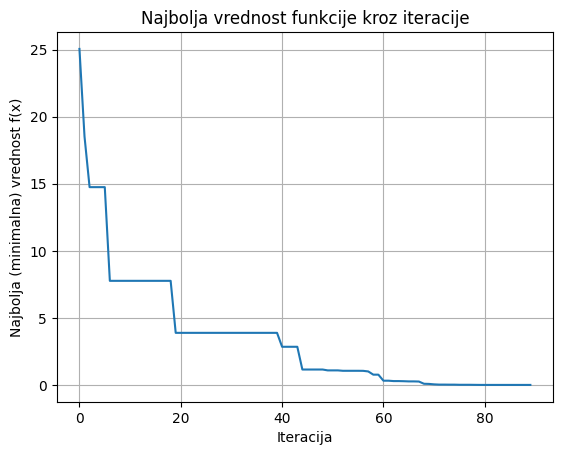

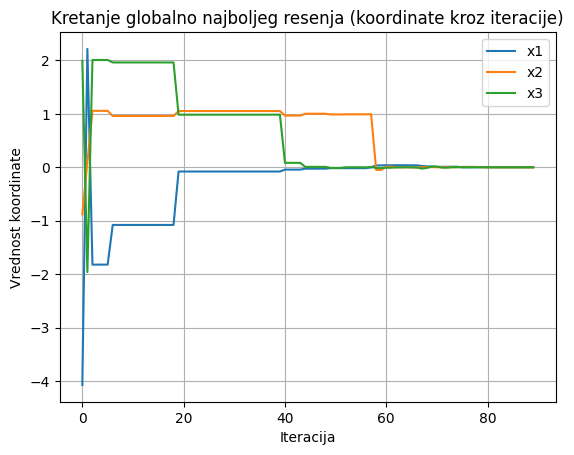

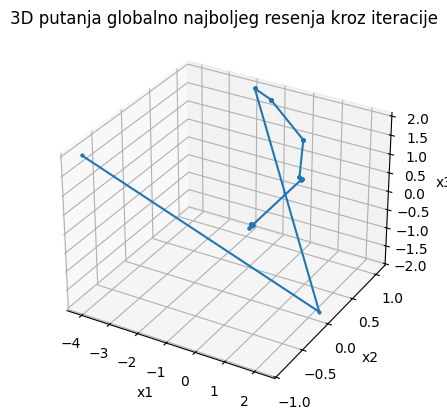

In [1]:
# =========================
# PSO za Rastrigin (d=3)
# 18 cestica, 90 iteracija
# domen: [-5.12, 5.12]
# =========================

import numpy as np
import random
import math
import matplotlib.pyplot as plt


# -------------------------
# Rastrigin funkcija
# -------------------------
def rastrigin(x):
    # x je lista ili niz duzine d (ovde d=3)
    d = len(x)
    return 10 * d + sum((xi**2 - 10 * math.cos(2 * math.pi * xi)) for xi in x)


# -------------------------
# Opcije (kao u skripti)
# -------------------------
class myOptions:
    def __init__(self):
        self.npart     = 30      # broj cestica (menjamo dole na 18)
        self.niter     = 100     # broj iteracija (menjamo dole na 90)

        # koeficijenti ubrzanja (menjaju se linearno)
        self.cbi       = 2.5     # pocetni cp (individual-best)
        self.cbf       = 0.5     # krajnji  cp
        self.cgi       = 0.5     # pocetni cg (global-best)
        self.cgf       = 2.5     # krajnji  cg

        # inercija (menja se linearno)
        self.wi        = 0.9     # pocetni w
        self.wf        = 0.4     # krajnji  w

        # inicijalizacija brzina
        self.vspaninit = 1

        # (ne komplikujemo dalje, ostalo ne koristimo ovde)
        self.vmax      = math.inf


# -------------------------
# Klasa cestice
# -------------------------
class Particle:
    def __init__(self, x0, num_dimensions, options):
        self.num_dimensions = num_dimensions

        # trenutna pozicija i brzina
        self.position_i = [x0[i][0] for i in range(num_dimensions)]
        self.velocity_i = [(np.random.rand() - 0.5) * 2 * options.vspaninit for _ in range(num_dimensions)]

        # najbolje licno
        self.pos_best_i = []
        self.fitness_best_i = -1

        # trenutni fitness
        self.fitness_i = -1

    def evaluate(self, costFunc):
        # izracunaj trenutnu vrednost funkcije
        self.fitness_i = costFunc(self.position_i)

        # ako je ovo najbolje do sada za ovu cestu, sacuvaj pbest
        if self.fitness_i < self.fitness_best_i or self.fitness_best_i == -1:
            self.pos_best_i = np.copy(self.position_i)
            self.fitness_best_i = float(self.fitness_i)

    def linrate(self, x_start, x_end, tmax, tmin, t):
        """
        Linearna promena parametra:
        na pocetku (t=tmin) je x_start,
        na kraju (t=tmax) je x_end.
        """
        # zastita da ne delimo sa nulom
        if tmax == tmin:
            return x_end
        return x_start + (x_end - x_start) * ((t - tmin) / (tmax - tmin))

    def update_velocity(self, pos_best_g, maxiter, iter_idx, opt):
        # linearno menjamo w, cp, cg kroz iteracije
        # maxiter-1 koristimo jer iteracije idu 0..maxiter-1
        w  = self.linrate(opt.wi,  opt.wf,  maxiter - 1, 0, iter_idx)
        cp = self.linrate(opt.cbi, opt.cbf, maxiter - 1, 0, iter_idx)
        cg = self.linrate(opt.cgi, opt.cgf, maxiter - 1, 0, iter_idx)

        for i in range(self.num_dimensions):
            r1 = random.random()
            r2 = random.random()

            # "kognitivni" deo (vuci ka svom pbest)
            vel_cognitive = cp * r1 * (self.pos_best_i[i] - self.position_i[i])

            # "socijalni" deo (vuci ka gbest)
            vel_social = cg * r2 * (pos_best_g[i] - self.position_i[i])

            # nova brzina
            v = w * self.velocity_i[i] + vel_cognitive + vel_social

            # ogranicenje brzine (ovde je inf, ali ostavljamo za slucaj da promenis)
            if math.isfinite(opt.vmax):
                v = max(-opt.vmax, min(opt.vmax, v))

            self.velocity_i[i] = v

    def update_position(self, lb, ub):
        # pomeri cestu i obavezno ostani u domenu
        for i in range(self.num_dimensions):
            self.position_i[i] = self.position_i[i] + self.velocity_i[i]

            # clamp na granice domena [-5.12, 5.12]
            # i zaustavi brzinu u toj dimenziji ako udari u zid
            if self.position_i[i] < lb[i]:
                self.position_i[i] = lb[i]
                self.velocity_i[i] = 0.0
            elif self.position_i[i] > ub[i]:
                self.position_i[i] = ub[i]
                self.velocity_i[i] = 0.0


# -------------------------
# PSO (glavni algoritam)
# -------------------------
class PSO:
    def __init__(self, costFunc, num_dimensions, options, lb, ub, seed=1):
        # seed da dobijas iste rezultate kad ponovis (lakse za proveru)
        random.seed(seed)
        np.random.seed(seed)

        self.pos_best_g = []
        self.fitness_best_g = -1

        self.best_history = []       # za graf najbolje vrednosti
        self.gbest_pos_history = []  # za putanju gbest-a

        maxiter = options.niter
        num_particles = options.npart

        lb = np.array(lb, dtype=float)
        ub = np.array(ub, dtype=float)

        # inicijalizacija populacije unutar domena
        population = []
        for _ in range(num_particles):
            # uniformno u [lb, ub] po dimenziji
            x0 = (np.random.rand(num_dimensions, 1)) * (ub - lb).reshape(-1, 1) + lb.reshape(-1, 1)
            population.append(Particle(x0, num_dimensions, options))

        fitness_best_g = -1
        pos_best_g = []

        # glavna petlja
        for it in range(maxiter):
            # 1) evaluacija i update gbest
            for p in population:
                p.evaluate(costFunc)

                if p.fitness_i < fitness_best_g or fitness_best_g == -1:
                    pos_best_g = list(p.position_i)
                    fitness_best_g = float(p.fitness_i)

            # 2) sacuvaj istoriju (pre pomeranja)
            self.best_history.append(fitness_best_g)
            self.gbest_pos_history.append(pos_best_g.copy())

            # 3) update brzina i pomeraj
            for p in population:
                p.update_velocity(pos_best_g, maxiter, it, options)
                p.update_position(lb, ub)

        # sacuvaj finalno najbolje
        self.pos_best_g = pos_best_g
        self.fitness_best_g = fitness_best_g


# =========================
# Podesavanja iz zadatka
# =========================
options = myOptions()
options.npart = 18   # 18 cestica
options.niter = 90   # 90 iteracija

d = 3
lb = [-5.12] * d
ub = [ 5.12] * d

# pokretanje PSO
solver = PSO(rastrigin, d, options, lb, ub, seed=1)

# =========================
# Ispis rezultata
# =========================
print("Najbolje nadjeno resenje (gbest):")
print(solver.pos_best_g)

print("\nMinimalna vrednost funkcije:")
print(solver.fitness_best_g)

# =========================
# Graf 1: najbolja vrednost kroz iteracije
# =========================
plt.figure()
plt.plot(solver.best_history)
plt.title("Najbolja vrednost funkcije kroz iteracije")
plt.xlabel("Iteracija")
plt.ylabel("Najbolja (minimalna) vrednost f(x)")
plt.grid(True)
plt.show()

# =========================
# Graf 2: kretanje gbest resenja kroz iteracije
# (prikaz po koordinatama + 3D putanja)
# =========================
gb = np.array(solver.gbest_pos_history)  # shape: (niter, 3)

# 2a) po koordinatama
plt.figure()
plt.plot(gb[:, 0], label="x1")
plt.plot(gb[:, 1], label="x2")
plt.plot(gb[:, 2], label="x3")
plt.title("Kretanje globalno najboljeg resenja (koordinate kroz iteracije)")
plt.xlabel("Iteracija")
plt.ylabel("Vrednost koordinate")
plt.grid(True)
plt.legend()
plt.show()

# 2b) 3D putanja (x1, x2, x3)
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.plot(gb[:, 0], gb[:, 1], gb[:, 2], marker="o", markersize=2)
ax.set_title("3D putanja globalno najboljeg resenja kroz iteracije")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
plt.show()
